# Проект. Исследование стартапов

- Автор: Екатерина Мирау
- Дата: 22.03.2026

## Введение

В рамках проекта проводится исследование данных о стартапах и их финансировании. Стартапы играют важную роль в развитии инновационной экономики, привлекая инвестиции на различных этапах своего развития. Анализ информации о привлечённом финансировании, рыночных сегментах компаний и типах инвестиционных инструментов позволяет выявить особенности инвестиционной активности, определить наиболее популярные способы финансирования и оценить динамику развития различных сегментов рынка.

Целью данного проекта является исследование структуры финансирования стартапов на основе предоставленных данных. В ходе работы необходимо изучить характеристики компаний, объёмы и типы финансирования, а также проанализировать динамику инвестиционной активности по годам. Особое внимание уделяется выявлению типичных значений объёма финансирования, обработке аномальных значений и анализу различий между рыночными сегментами.

В процессе исследования будут выполнены следующие этапы: загрузка и предобработка данных, формирование дополнительных признаков, анализ структуры рынка и выявление выбросов, изучение типов финансирования по объёму и популярности, а также анализ динамики инвестиционной активности и возврата средств по годам.

По итогам анализа необходимо сформулировать рекомендации для инвестора, исходя из ситуации на рынке на 2015 год. На основе полученных результатов будет предложено, в какой рыночный сегмент целесообразно инвестировать и какой тип финансирования может быть наиболее подходящим с точки зрения объёмов инвестиций, популярности и динамики возврата средств.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
# Импортируем библиотеку для работы с таблицами
import pandas as pd

# Импортируем библиотеку для числовых вычислений
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [2]:
# Загружаем основной датасет со стартапами
df = pd.read_csv(
    "https://code.s3.yandex.net/datasets/cb_investments.zip",
    sep=';',
    low_memory=False
)

# Загружаем датасет с информацией о возврате инвестиций
cb_returns = pd.read_csv(
    "https://code.s3.yandex.net/datasets/cb_returns.csv"
)

Выведите информацию, которая необходима для принятия решений о предобработке.

In [3]:
# Выведем первые строки датасета со стартапами, чтобы ознакомиться со структурой таблицы
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Получим общую информацию о таблице:
# названия столбцов, количество непропущенных значений и типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
# Посчитаем количество пропусков в каждом столбце
df.isna().sum().sort_values(ascending=False)

state_code              24133
mid_funding_at          24006
participants            23821
founded_month           15812
founded_quarter         15812
founded_at              15740
founded_year            15740
city                    10972
country_code            10129
region                  10129
category_list            8817
 market                  8817
homepage_url             8305
status                   6170
name                     4857
private_equity           4856
round_E                  4856
round_F                  4856
round_D                  4856
round_C                  4856
round_G                  4856
round_B                  4856
round_A                  4856
product_crowdfunding     4856
secondary_market         4856
post_ipo_debt            4856
post_ipo_equity          4856
venture                  4856
grant                    4856
angel                    4856
debt_financing           4856
convertible_note         4856
undisclosed              4856
equity_cro

In [6]:
# Проверим, есть ли в таблице полные дубликаты строк
df.duplicated().sum()

4855

In [7]:
# Выведем первые строки датасета с данными о возврате средств
cb_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [8]:
# Получим общую информацию о таблице
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [9]:
# Посчитаем количество пропусков в каждом столбце
cb_returns.isna().sum()

year                    0
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
dtype: int64

Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

В ходе первичного анализа был изучен датасет со сведениями о стартапах и их финансировании. Таблица содержит **54 294 строки и 40 столбцов**, что соответствует описанию проекта.

В данных присутствуют **пропущенные значения** в ряде столбцов, в частности `state_code`, `mid_funding_at`, `participants`, `founded_at`, `city`, `country_code`, `region`, `category_list` и `market`. На этапе предобработки потребуется определить способ их обработки.

Также было обнаружено **4855 полных дубликатов**, которые необходимо удалить.

Некоторые столбцы требуют приведения к корректным типам данных. В частности, столбцы с датами (`founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at`) следует преобразовать в формат `datetime`, а столбец `funding_total_usd` — в числовой формат.

Таким образом, на следующем этапе будет проведена предобработка данных: удаление дубликатов, обработка пропусков и корректировка типов данных.

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [10]:
# Выведем список всех столбцов датасета
df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [11]:
# Удалим лишние пробелы в названиях столбцов
df.columns = df.columns.str.strip()

In [12]:
# Снова выведем список столбцов
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

Названия столбцов были проверены. В целом они оформлены в удобном для работы стиле: используются строчные буквы и разделение слов символом нижнего подчёркивания (snake_case).
Однако у некоторых столбцов были обнаружены лишние пробелы в названиях (`market ` и `funding_total_usd `). Эти пробелы были удалены, чтобы избежать возможных ошибок при обращении к столбцам.
После очистки названия столбцов приведены к единому аккуратному стилю.

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [13]:
# Удалим разделители разрядов (запятые)
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '')

# Преобразуем столбец в числовой тип, все некорректные значения превратятся в NaN
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

In [14]:
# Проверим тип данных
df['funding_total_usd'].dtype

dtype('float64')

In [15]:
# При желании можно уменьшить разрядность числовых столбцов,
# чтобы сократить использование памяти
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce', downcast='float')

In [16]:
# Проверим тип данных
df['funding_total_usd'].dtype

dtype('float32')

In [17]:
# Посмотрим количество пропусков
df['funding_total_usd'].isna().sum()

13387

В столбце `funding_total_usd` значения были представлены в строковом формате и содержали разделители разрядов (запятые). Разделители были удалены, после чего столбец был приведён к числовому типу данных.
Некорректные значения были автоматически заменены на пропущенные (`NaN`). После преобразования тип данных столбца — `float64`, что позволяет использовать его для дальнейшего анализа.

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [18]:
# Сохраним названия столбцов с датами в отдельный список
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

# Преобразуем столбцы с датами в формат datetime
# Некорректные значения автоматически заменятся на NaT
df[date_columns] = df[date_columns].apply(pd.to_datetime, errors='coerce')

In [19]:
# Проверим типы данных после преобразования
df[date_columns].dtypes

founded_at          datetime64[ns]
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
dtype: object

In [20]:
# Посмотрим, сколько пропусков стало в столбцах с датами
df[date_columns].isna().sum()

founded_at          15741
first_funding_at     4866
mid_funding_at      24006
last_funding_at      4862
dtype: int64

Столбцы `founded_at`, `first_funding_at`, `mid_funding_at` и `last_funding_at`, содержащие даты, были преобразованы из типа `object` в формат `datetime`. 
При преобразовании использовался параметр `errors='coerce'`, поэтому некорректные или выходящие за допустимые границы значения были автоматически заменены на пропуски (`NaT`). 
После преобразования в столбцах наблюдаются пропущенные значения: наибольшее их количество находится в столбце `mid_funding_at`. Эти пропуски будут обработаны на следующих этапах предобработки.

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [21]:
# Сделаем столбец year индексом датасета
cb_returns = cb_returns.set_index('year')

In [22]:
# Проверим, что year стал индексом
cb_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


В датасете `cb_returns` столбец `year` был установлен в качестве индекса таблицы. 

Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [23]:
# Проверим наличие 'unknown' в нескольких столбцах
columns = ['market', 'category_list', 'city', 'region', 'state_code', 'country_code']

for col in columns:
    print(col, (df[col] == 'unknown').sum())

market 0
category_list 0
city 0
region 0
state_code 0
country_code 0


In [24]:
# Заполним пропуски в текстовых столбцах заглушками
df['market'] = df['market'].fillna('unknown')
df['category_list'] = df['category_list'].fillna('unknown')
df['city'] = df['city'].fillna('unknown')
df['region'] = df['region'].fillna('unknown')
df['state_code'] = df['state_code'].fillna('unknown')
df['country_code'] = df['country_code'].fillna('unknown')

In [25]:
# Проверим, остались ли пропуски
df[['market', 'category_list', 'city', 'region', 'state_code', 'country_code']].isna().sum()

market           0
category_list    0
city             0
region           0
state_code       0
country_code     0
dtype: int64

Перед заполнением пропусков была выполнена проверка на наличие значения `unknown` в исходных данных (по всем рассматриваемым столбцам количество таких значений равно 0). Это позволило убедиться, что выбранная заглушка не пересекается с реальными значениями. После этого пропуски были заполнены значением `unknown`.

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [26]:
# Удалим полные дубликаты строк
df = df.drop_duplicates()

In [27]:
# Удаление пропусков
df = df.dropna(subset=['funding_total_usd'])

In [28]:
# Проверим размер датасета после очистки
df.shape

(40907, 40)

In [29]:
# Проверим, остались ли пропуски
df['funding_total_usd'].isna().sum()

0

In [30]:
# Посчитаем долю удалённых строк и округлим до 2 знаков
removed_share = (54294 - 40907) / 54294 * 100
round(removed_share, 2)

24.66

Данные были проверены на наличие полных дубликатов, которые были удалены.
В столбце `funding_total_usd` были обнаружены пропущенные значения. Поскольку данный столбец является ключевым для анализа, строки без информации о финансировании были исключены из датасета.
После очистки в таблице осталось 40 907 строк. Было удалено 24.66% данных. Таким образом, в датасете остались только данные, содержащие релевантную информацию для анализа финансирования стартапов.

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [31]:
# Заполним пропуски в mid_funding_at серединой интервала
df['mid_funding_at'] = df['mid_funding_at'].fillna(
    df['first_funding_at'] + (df['last_funding_at'] - df['first_funding_at']) / 2
)

In [32]:
# Посмотрим, сколько пропусков осталось
df['mid_funding_at'].isna().sum()

1

Пропущенные значения в столбце `mid_funding_at` были заполнены на основе данных о первом и последнем раундах финансирования.
В качестве оценки использовалась середина интервала между датами `first_funding_at` и `last_funding_at`. Такой подход позволяет получить приближённую дату среднего раунда финансирования при отсутствии точных данных.
После заполнения практически все пропуски были устранены — в столбце осталось всего 1 пропущенное значение, что связано с отсутствием данных о первом или последнем раунде финансирования.

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

В ходе предобработки данных были удалены полные дубликаты и строки с пропущенными значениями в столбце `funding_total_usd`, так как данный показатель является ключевым для анализа. 

В результате было удалено 24.66% данных, после чего в датасете осталось 40 907 наблюдений.

Дополнительно были обработаны пропуски в столбце `mid_funding_at`: почти все значения удалось восстановить на основе информации о первом и последнем раундах финансирования. В столбце остался всего 1 пропуск, что не оказывает существенного влияния на дальнейший анализ.

Несмотря на сокращение объёма данных, оставшаяся выборка остаётся достаточно большой и репрезентативной для проведения исследования. Таким образом, данных достаточно для решения задач проекта и получения обоснованных аналитических выводов.

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [33]:
# Создадим столбец с длительностью финансирования (в днях)
df['funding_duration_days'] = (
    df['last_funding_at'] - df['first_funding_at']
).dt.days

In [34]:
# Функция для классификации
def funding_group(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_duration_days'] <= 365:
        return 'До года'
    else:
        return 'Более года'

In [35]:
# Применим функцию
df['funding_group'] = df.apply(funding_group, axis=1)

In [36]:
# Посчитаем доли
group_counts = df['funding_group'].value_counts(normalize=True) * 100

In [37]:
# Цветовая палитра для графиков
palette = {
    'Единичное финансирование': '#4E79A7',
    'До года': '#59A14F',
    'Более года': '#F28E2B'
}

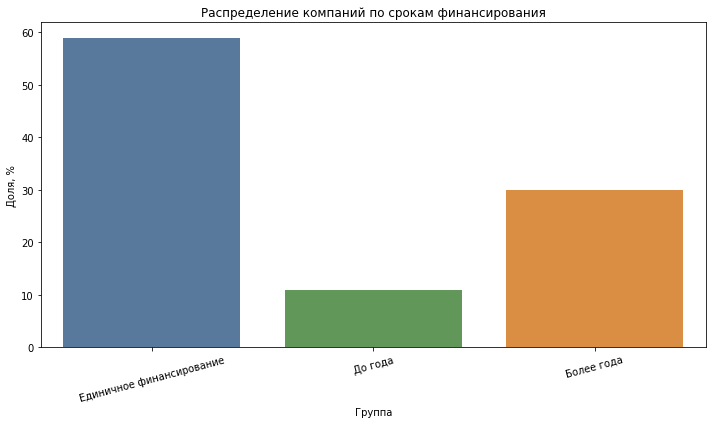

In [38]:
# Зададим логичный порядок категорий
order = ['Единичное финансирование', 'До года', 'Более года']

# Перестроим серии в нужном порядке
group_counts = group_counts.reindex(order)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(
    x=group_counts.index,
    y=group_counts.values,
    palette=palette
)

plt.title('Распределение компаний по срокам финансирования')
plt.ylabel('Доля, %')
plt.xlabel('Группа')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [39]:
# Сумма инвестиций по группам
group_funding = df.groupby('funding_group')['funding_total_usd'].sum()

In [40]:
# Доли
group_funding_share = group_funding / group_funding.sum() * 100

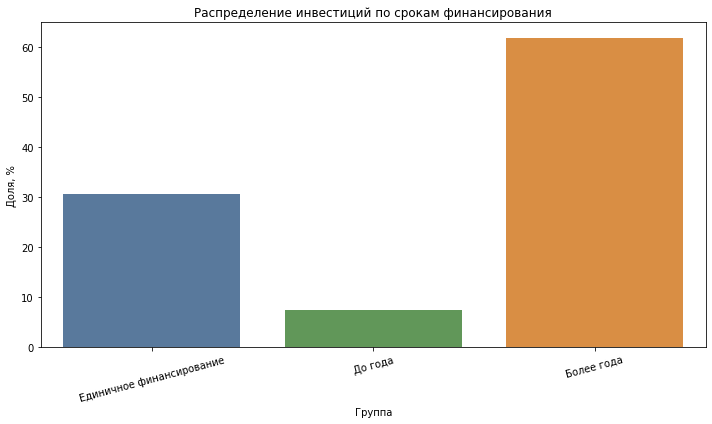

In [41]:
# Зададим логичный порядок категорий
order = ['Единичное финансирование', 'До года', 'Более года']

# Перестроим серии в нужном порядке
group_funding_share = group_funding_share.reindex(order)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(
    x=group_funding_share.index,
    y=group_funding_share.values,
    palette=palette
)

plt.title('Распределение инвестиций по срокам финансирования')
plt.ylabel('Доля, %')
plt.xlabel('Группа')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Компании были разделены на группы в зависимости от длительности финансирования: единичное финансирование, срок до года и более года.

Анализ показал, что наибольшая доля компаний (около 60%) привлекает финансирование в рамках одного раунда. При этом около 30% компаний проходят длительный цикл финансирования (более года), а доля компаний со сроком финансирования до года составляет наименьшую часть (около 10%).

Однако распределение объёма инвестиций существенно отличается от распределения количества компаний. Основной объём инвестиций (более 60%) приходится на компании с длительным периодом финансирования (более года), несмотря на то что их доля по количеству ниже.

Компании с единичным раундом финансирования составляют значительную часть выборки, но привлекают существенно меньшую долю инвестиций (около 30%). Наименее значимую роль играют компании с краткосрочным финансированием (до года) — как по количеству, так и по объёму инвестиций.

Таким образом, можно сделать вывод, что более длительные циклы финансирования характерны для компаний, привлекающих наибольшие инвестиции, тогда как большинство компаний ограничивается одним раундом и меньшими объёмами финансирования.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

In [42]:
# Проверяем количество unknown
unknown_count = (df['market'] == 'unknown').sum()
unknown_count

2503

In [43]:
# Убираем unknown
df_market = df[df['market'] != 'unknown']

In [44]:
# Считаем количество компаний в каждом сегменте
market_counts = df_market['market'].value_counts()

In [45]:
# Классифицируем сегменты
def segment_type(count):
    if count > 120:
        return 'Массовый'
    elif 35 <= count <= 120:
        return 'Средний'
    else:
        return 'Нишевый'

In [46]:
# Применяем классификацию
market_segments = market_counts.reset_index()
market_segments.columns = ['market', 'company_count']

market_segments['segment_type'] = market_segments['company_count'].apply(segment_type)

In [47]:
# Считаем количество сегментов в каждой категории
segment_summary = market_segments['segment_type'].value_counts()
segment_summary

Нишевый     714
Средний      81
Массовый     53
Name: segment_type, dtype: int64

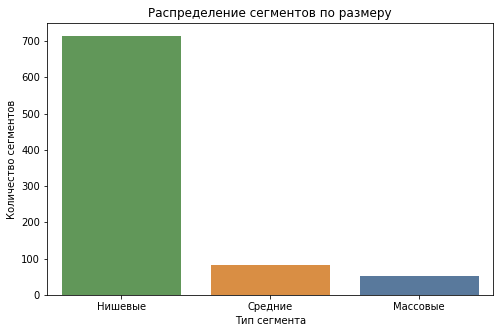

In [48]:
# Создаём категории
market_segments['group'] = pd.cut(
    market_segments['company_count'],
    bins=[0, 35, 120, market_segments['company_count'].max()],
    labels=['Нишевые', 'Средние', 'Массовые'],
    include_lowest=True
)

# Считаем количество сегментов
group_counts = market_segments['group'].value_counts()

# График
plt.figure(figsize=(8, 5))

sns.barplot(
    x=group_counts.index,
    y=group_counts.values,
    palette=['#59A14F', '#F28E2B', '#4E79A7']
)

plt.title('Распределение сегментов по размеру')
plt.xlabel('Тип сегмента')
plt.ylabel('Количество сегментов')

plt.show()


В датасете представлено множество рыночных сегментов, при этом подавляющее большинство из них относится к нишевым (до 35 компаний). Средние сегменты (от 35 до 120 компаний) встречаются значительно реже, а массовые сегменты (более 120 компаний) составляют наименьшую долю.

График распределения показывает, что основная концентрация сегментов находится в области малых значений, что подтверждает сильную фрагментацию рынка. Границы на уровне 35 и 120 компаний чётко разделяют сегменты на нишевые, средние и массовые.

Оставьте в столбце market только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche`для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.

In [49]:
# Присоединяем тип сегмента к основному датафрейму
df_market = df_market.merge(
    market_segments[['market', 'segment_type']],
    on='market',
    how='left'
)

In [50]:
# Заменяем средние сегменты на 'mid'
df_market.loc[df_market['segment_type'] == 'Средний', 'market'] = 'mid'

# Заменяем нишевые сегменты на 'niche'
df_market.loc[df_market['segment_type'] == 'Нишевый', 'market'] = 'niche'

In [51]:
# Проверяем уникальные значения
df_market['market'].value_counts()

mid                       5069
 Software                 4190
 Biotechnology            3531
niche                     2494
 Mobile                   1852
 E-Commerce               1528
 Curated Web              1404
 Enterprise Software      1190
 Health Care              1128
 Clean Technology         1094
 Hardware + Software      1008
 Games                     986
 Advertising               954
 Health and Wellness       825
 Social Media              787
 Education                 736
 Finance                   728
 Analytics                 565
 Manufacturing             564
 Security                  491
 Semiconductors            473
 Web Hosting               400
 Consulting                322
 Hospitality               313
 Travel                    293
 Fashion                   285
 News                      284
 Messaging                 264
 Real Estate               251
 Music                     246
 Search                    242
Software                   240
 Technol

После классификации сегментов по размеру были выполнены преобразования в столбце `market`. Массовые сегменты оставлены без изменений, а средние и нишевые сегменты объединены в категории `mid` и `niche` соответственно.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

In [52]:
df_market['funding_total_usd'].describe()

count    3.840400e+04
mean     1.628406e+07
std      1.710276e+08
min      1.000000e+00
25%      4.000000e+05
50%      2.100000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

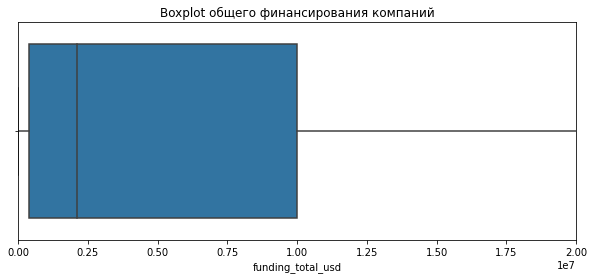

In [53]:
# Строим boxplot для оценки распределения и выбросов
plt.figure(figsize=(10, 4))

sns.boxplot(x=df_market['funding_total_usd'])

# Ограничиваем ось, чтобы увидеть основную массу значений
plt.xlim(0, 2e7)

plt.title('Boxplot общего финансирования компаний')

plt.show()

Анализ распределения общего финансирования с помощью boxplot показал, что данные имеют выраженную правостороннюю асимметрию и содержат значительное количество выбросов.

Основная масса наблюдений сосредоточена в диапазоне от 0.4 до 10 млн долларов, что соответствует интерквартильному диапазону. Медианное значение составляет около 2.1 млн долларов.

Таким образом, типичный размер финансирования для одной компании находится в пределах от 0.4 до 10 млн долларов. Значения, существенно превышающие этот диапазон, можно считать выбросами.

При этом максимальные значения достигают десятков миллиардов долларов, что существенно искажает распределение.

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [54]:
# функция для определения выбросов
def get_outliers(group):
    Q1 = group['funding_total_usd'].quantile(0.25)
    Q3 = group['funding_total_usd'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    
    return group[(group['funding_total_usd'] < lower) | 
                 (group['funding_total_usd'] > upper)]

# применяем по сегментам
outliers = df_market.groupby('market').apply(get_outliers).reset_index(drop=True)

In [55]:
# общее количество компаний по сегментам
total = df_market.groupby('market')['funding_total_usd'].count()

# количество выбросов
outliers_count = outliers.groupby('market')['funding_total_usd'].count()

# доля выбросов
outliers_share = (outliers_count / total).sort_values(ascending=False)

outliers_share

market
E-Commerce                0.139535
 Real Estate              0.139442
 Internet                 0.128571
 SaaS                     0.125000
 Entertainment            0.124088
 Technology               0.117904
 Photography              0.112245
 Social Media             0.108005
 Cloud Computing          0.106870
niche                     0.102646
 Consulting               0.102484
 Marketplaces             0.102273
 Design                   0.100000
 Travel                   0.098976
 Music                    0.097561
 E-Commerce               0.097513
 Search                   0.095041
 Apps                     0.094059
mid                       0.093707
 Big Data                 0.092857
 Social Network Media     0.092715
 Networking               0.089552
 Hospitality              0.089457
Mobile                    0.089005
 Automotive               0.085714
 Education                0.085598
 Health and Wellness      0.084848
 Fashion                  0.084211
 Clean Techno

In [56]:
outliers_share.head()

market
E-Commerce         0.139535
 Real Estate       0.139442
 Internet          0.128571
 SaaS              0.125000
 Entertainment     0.124088
Name: funding_total_usd, dtype: float64

Для выявления аномальных значений объёма финансирования был применён метод межквартильного размаха (IQR) отдельно для каждого сегмента рынка. С учётом выраженной правосторонней асимметрии распределения границы выбросов были расширены с использованием коэффициента 3 вместо стандартного 1.5.

Для каждого сегмента были рассчитаны квартильные значения и определены скорректированные границы выбросов. Компании, значения финансирования которых выходят за эти границы, были отнесены к аномальным.

Далее была рассчитана доля таких компаний в каждом сегменте. Наибольшая доля компаний с аномальным финансированием наблюдается в сегментах E-Commerce (14%), Real Estate (13.9%), Internet (12.9%), SaaS (2.5%) и Entertainment (12.4%).

Полученные результаты свидетельствуют о том, что после корректировки метода доля выбросов снизилась, и теперь в качестве аномальных выделяются преимущественно действительно экстремальные значения. Это позволяет более корректно оценивать вариативность инвестиций и снижает влияние сильно скошенного распределения.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [57]:
# создаём столбец с годом
df_market['funding_year'] = pd.to_datetime(df_market['mid_funding_at']).dt.year

# смотрим распределение по годам
df_market['funding_year'].value_counts().sort_index()

1960.0       2
1979.0       1
1984.0       2
1987.0       1
1989.0       1
1990.0       1
1992.0       1
1993.0       1
1994.0       3
1995.0       4
1996.0       4
1997.0       7
1998.0      13
1999.0      46
2000.0      96
2001.0      49
2002.0      64
2003.0      86
2004.0     138
2005.0     820
2006.0    1428
2007.0    2082
2008.0    2541
2009.0    3067
2010.0    3907
2011.0    4666
2012.0    5716
2013.0    7890
2014.0    5766
Name: funding_year, dtype: int64

In [58]:
# создаём столбец с месяцем финансирования для проверки полноты 2014 года
df_market['funding_month'] = pd.to_datetime(df_market['mid_funding_at']).dt.month

# оставляем только записи за 2014 год
df_2014 = df_market[df_market['funding_year'] == 2014]

# считаем количество записей по месяцам
months_2014 = df_2014['funding_month'].value_counts().sort_index()

months_2014

1.0     652
2.0     530
3.0     609
4.0     577
5.0     540
6.0     627
7.0     617
8.0     510
9.0     476
10.0    406
11.0    209
12.0     13
Name: funding_month, dtype: int64

In [86]:
# функция для пометки выбросов по методу IQR с коэффициентом 1.5
def mark_outliers(group):
    Q1 = group['funding_total_usd'].quantile(0.25)
    Q3 = group['funding_total_usd'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    group['is_outlier'] = (
        (group['funding_total_usd'] < lower) |
        (group['funding_total_usd'] > upper)
    )
    
    return group

In [60]:
# применяем функцию по сегментам рынка
df_market = df_market.groupby('market', group_keys=False).apply(mark_outliers)

In [61]:
# исключаем аномалии
df_clean = df_market[df_market['is_outlier'] == False]

In [62]:
# считаем общее количество раундов финансирования по годам
rounds_per_year = df_clean.groupby('funding_year')['funding_rounds'].sum()

rounds_per_year

funding_year
1960.0        2.0
1979.0        1.0
1984.0        2.0
1987.0        1.0
1989.0        1.0
1990.0        1.0
1992.0        2.0
1993.0        1.0
1994.0        3.0
1995.0        9.0
1996.0        8.0
1997.0        9.0
1998.0       15.0
1999.0       41.0
2000.0      113.0
2001.0       58.0
2002.0       97.0
2003.0      124.0
2004.0      160.0
2005.0      926.0
2006.0     1828.0
2007.0     2820.0
2008.0     3632.0
2009.0     4502.0
2010.0     5985.0
2011.0     7370.0
2012.0     9311.0
2013.0    12347.0
2014.0     6367.0
Name: funding_rounds, dtype: float64

In [63]:
# оставляем только годы, в которых было 50 и более раундов финансирования
valid_years = rounds_per_year[rounds_per_year >= 50].index

valid_years

Float64Index([2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0,
              2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0],
             dtype='float64', name='funding_year')

In [64]:
# фильтруем датасет: оставляем только компании из нужных лет
df_final = df_clean[df_clean['funding_year'].isin(valid_years)]

In [65]:
# проверяем распределение по годам после всех фильтраций
df_final['funding_year'].value_counts().sort_index()

2000.0      62
2001.0      29
2002.0      47
2003.0      62
2004.0      86
2005.0     681
2006.0    1147
2007.0    1580
2008.0    1952
2009.0    2491
2010.0    3327
2011.0    4141
2012.0    5195
2013.0    7348
2014.0    5366
Name: funding_year, dtype: int64

По распределению количества раундов финансирования видно, что до 2000 года наблюдается крайне низкая активность, что может указывать на неполноту или нерепрезентативность данных за этот период.

Для проверки полноты 2014 года дополнительно было проанализировано распределение записей по месяцам на основе столбца `mid_funding_at`. Проверка показала, что данные присутствуют за все 12 месяцев, следовательно, 2014 год можно считать полным.

Затем из датасета были исключены компании с аномальным объёмом финансирования, выявленные по методу IQR с коэффициентом 3 отдельно для каждого сегмента рынка. После этого было рассчитано суммарное количество раундов финансирования по годам.

В итоговый датасет были включены только те компании, которые получали финансирование в годы, когда было зафиксировано не менее 50 раундов финансирования. По результатам фильтрации для дальнейшего анализа были оставлены данные за период с 2000 по 2014 год.

Таким образом, дальнейший анализ проводится на очищенных и репрезентативных данных, без аномальных наблюдений и с учётом только тех лет, в которых рыночная активность была достаточной для анализа.

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

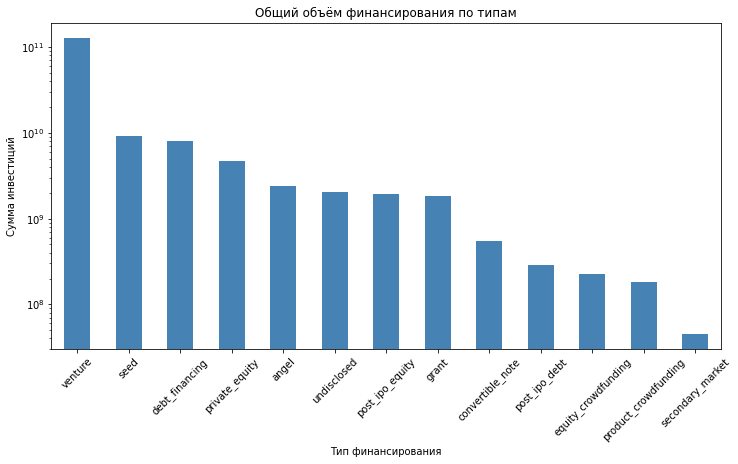

In [66]:
# список столбцов с типами финансирования
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# считаем общий объём по каждому типу
funding_sum = df_final[funding_types].sum().sort_values(ascending=False)

# строим график
funding_sum.plot(kind='bar', figsize=(12,6), logy=True, color='steelblue')

# подписи
plt.title('Общий объём финансирования по типам')
plt.ylabel('Сумма инвестиций')
plt.xlabel('Тип финансирования')

plt.xticks(rotation=45)
plt.show()

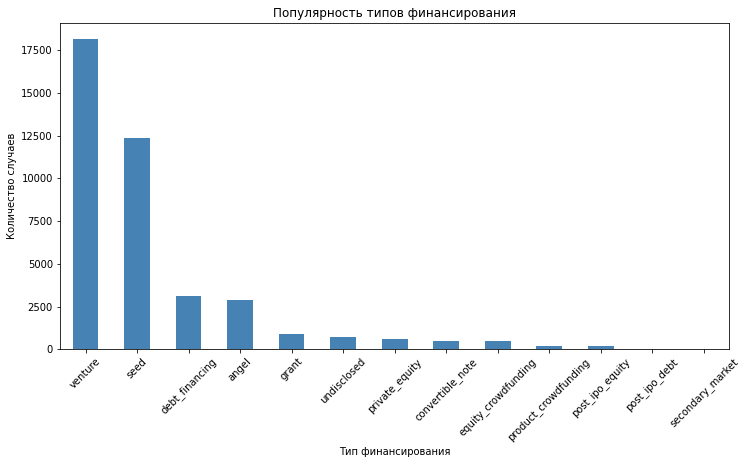

In [67]:
# считаем количество ненулевых значений
funding_count = (df_final[funding_types] > 0).sum().sort_values(ascending=False)

# строим график
funding_count.plot(
    kind='bar',
    figsize=(12,6),
    color='steelblue'
)

# подписи
plt.title('Популярность типов финансирования')
plt.ylabel('Количество случаев')
plt.xlabel('Тип финансирования')

plt.xticks(rotation=45)

plt.show()

Сравнение графиков показывает различия между частотой использования типов финансирования и объёмами привлекаемых средств.

**Часто используемые, но с относительно небольшими объёмами:**
- seed  
- angel  
- grant  

Эти типы финансирования характерны для ранних стадий развития компаний и используются часто, но объёмы инвестиций по ним относительно невелики.

**Редко используемые, но с крупными объёмами:**
- private_equity  
- post_ipo_equity  
- post_ipo_debt  

Эти инструменты применяются на более поздних стадиях развития компаний и связаны с привлечением значительных сумм, несмотря на редкость использования.

**Тип финансирования, сочетающий высокую популярность и значительный объём:**
- venture  

Данный тип финансирования является ключевым на рынке: он широко используется и при этом обеспечивает наибольший общий объём инвестиций.

Таким образом, структура финансирования отражает этапы развития компаний: от частых, но небольших инвестиций на ранних стадиях до редких, но крупных вложений на поздних этапах.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

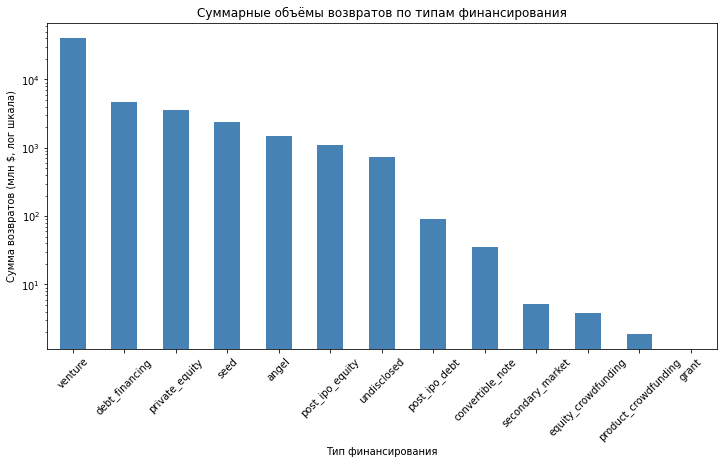

In [68]:
# список типов (без year)
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# считаем суммарные возвраты за весь период
returns_sum = cb_returns[funding_types].sum().sort_values(ascending=False)

# строим график
returns_sum.plot(
    kind='bar',
    figsize=(12,6),
    logy=True,
    color='steelblue'
)

# подписи
plt.title('Суммарные объёмы возвратов по типам финансирования')
plt.ylabel('Сумма возвратов (млн $, лог шкала)')
plt.xlabel('Тип финансирования')

plt.xticks(rotation=45)

plt.show()

Наибольшие суммарные объёмы возвратов приходятся на venture, что подтверждает его ключевую роль как основного инструмента финансирования и генерации прибыли на рынке.

Также значительные возвраты демонстрируют debt_financing и private_equity, что связано с крупными вложениями на более зрелых стадиях развития компаний.

Типы финансирования ранних стадий (seed, angel) обеспечивают меньшие объёмы возвратов, несмотря на их относительно высокую распространённость. Это объясняется меньшими размерами инвестиций на ранних этапах.

Наименее значительные возвраты характерны для таких типов, как product_crowdfunding, equity_crowdfunding и grant, что связано с их ограниченными масштабами и спецификой использования.

Таким образом, наблюдается чёткая зависимость: более зрелые и капиталоёмкие инструменты финансирования обеспечивают более высокие возвраты, тогда как массовые и ранние формы инвестирования характеризуются меньшей доходностью.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [69]:
# убираем строки с 0 раундов 
df_final = df_final[df_final['funding_rounds'] > 0]

# считаем средний размер одного раунда
df_final['avg_round'] = df_final['funding_total_usd'] / df_final['funding_rounds']

In [87]:
# медианный размер раунда по годам
avg_round_by_year = df_final.groupby('funding_year')['avg_round'].median()

# переводим размер раунда в миллионы долларов для удобства чтения графика
avg_round_by_year_mln = avg_round_by_year / 1e6

In [88]:
# считаем общее количество раундов по годам
rounds_by_year = df_final.groupby('funding_year')['funding_rounds'].sum()

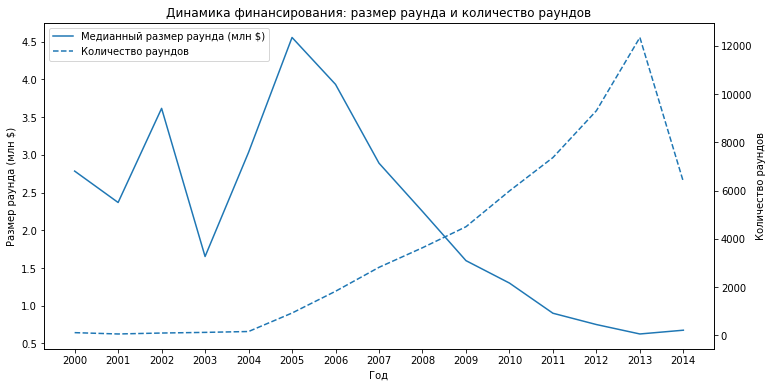

In [89]:
# строим объединённый график с двумя осями Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# график медианного размера одного раунда
ax1.plot(
    avg_round_by_year_mln.index,
    avg_round_by_year_mln,
    label='Медианный размер раунда (млн $)'
)
ax1.set_xlabel('Год')
ax1.set_ylabel('Размер раунда (млн $)')
ax1.set_xticks(avg_round_by_year_mln.index)

# график количества раундов на второй оси
ax2 = ax1.twinx()
ax2.plot(
    rounds_by_year.index,
    rounds_by_year,
    linestyle='--',
    label='Количество раундов'
)
ax2.set_ylabel('Количество раундов')

# заголовок
plt.title('Динамика финансирования: размер раунда и количество раундов')

# объединяем легенды с двух осей
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

In [90]:
# определяем год с максимальным типичным размером раунда
max_year = avg_round_by_year.idxmax()
max_value = avg_round_by_year.max()

print('Год с максимальным типичным размером раунда:', int(max_year))
print('Максимальный медианный размер раунда:', round(max_value / 1e6, 2), 'млн $')

Год с максимальным типичным размером раунда: 2005
Максимальный медианный размер раунда: 4.56 млн $


Максимальный типичный размер финансирования в рамках одного раунда наблюдался в **2005 году** и составил около **4.56 млн долларов**.

После этого показатель в целом демонстрирует нисходящую динамику. Это может свидетельствовать о том, что рынок постепенно смещался в сторону **более частых, но менее крупных инвестиций**, что характерно для роста числа ранних стадий финансирования.

При этом динамика количества раундов показывает обратную тенденцию:  
общее число раундов **стабильно росло вплоть до 2013 года**, что указывает на увеличение инвестиционной активности на рынке.

В **2014 году** наблюдается следующая картина:
- количество раундов **сократилось по сравнению с 2013 годом**;
- медианный размер одного раунда при этом **перестал снижаться и немного стабилизировался / слегка вырос**.

Это может говорить о том, что рынок вошёл в фазу **снижения общей активности**, при которой инвесторы стали **более избирательны**, отдавая предпочтение меньшему числу, но более качественных или крупных сделок.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [74]:
# оставляем только массовые сегменты
df_mass = df_final[~df_final['market'].isin(['mid', 'niche'])]

# проверяем, что в market остались только массовые сегменты
df_mass['market'].value_counts()

 Software                 3673
 Biotechnology            3159
 Mobile                   1625
 E-Commerce               1313
 Curated Web              1242
 Enterprise Software      1060
 Health Care              1007
 Clean Technology          955
 Hardware + Software       892
 Games                     883
 Advertising               838
 Health and Wellness       716
 Social Media              678
 Education                 646
 Finance                   636
 Manufacturing             508
 Analytics                 500
 Semiconductors            440
 Security                  436
 Web Hosting               358
 Consulting                271
 Hospitality               269
 Travel                    248
 Fashion                   248
 News                      246
 Messaging                 232
 Music                     216
Software                   213
 Real Estate               205
 Search                    202
 Technology                191
 SaaS                      189
 Interne

In [75]:
# сводная таблица по годам и сегментам
pivot = df_mass.pivot_table(
    values='funding_total_usd',
    index='funding_year',
    columns='market',
    aggfunc='sum'
)

# сортируем годы
pivot = pivot.sort_index()

In [76]:
# сегменты, где 2014 > 2013
growing = pivot.loc[2014] > pivot.loc[2013]

pivot_growth = pivot.loc[:, growing]

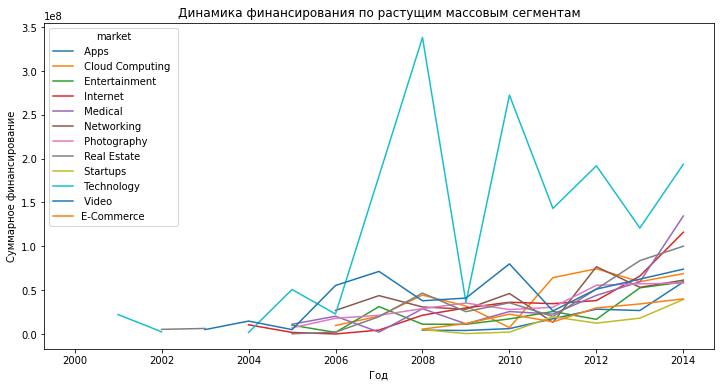

In [77]:
# строим график

pivot_growth.plot(figsize=(12,6))

plt.title('Динамика финансирования по растущим массовым сегментам')
plt.ylabel('Суммарное финансирование')
plt.xlabel('Год')

plt.show()

Анализ динамики суммарного финансирования по массовым сегментам, показавшим рост в 2014 году, позволяет выделить несколько ключевых тенденций.

Наиболее крупным сегментом является Technology, который демонстрирует самые высокие объёмы финансирования на протяжении всего периода. Однако его динамика характеризуется значительной волатильностью, с резкими скачками и падениями.

Наиболее устойчивый и уверенный рост наблюдается в сегментах E-Commerce, Cloud Computing, Medical и Real Estate. Для них характерно постепенное увеличение объёмов финансирования без существенных спадов, особенно заметное после 2011 года.

Сегменты Apps, Internet и Networking также демонстрируют положительную динамику, однако их рост менее выражен и не сопровождается ускорением.

Таким образом, наиболее перспективными можно считать сегменты с устойчивым и равномерным ростом, тогда как сегмент Technology остаётся лидером по объёму инвестиций, но с более высокой степенью нестабильности.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [78]:
# список типов (как раньше)
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

In [79]:
# сумма инвестиций по годам и типам
investments_by_year = df_final.groupby('funding_year')[funding_types].sum()

In [80]:
returns_by_year = cb_returns[funding_types]

In [81]:
# защита от деления на 0
epsilon = 1e-6

returns_ratio = returns_by_year / (investments_by_year + epsilon)

In [82]:
# убираем неадекватные значения
returns_ratio = returns_ratio.where(returns_ratio <= 1)

In [83]:
returns_ratio.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,9.985566e-07,1.735820e-07,0.0,6.197176e-07,0.000000e+00,6.185714e-07,2.464892e-07,0.0,0.000000e+00,2.710694e-07,0.0,2.591054e-08,0.0
2001,1.079592e-06,1.115338e-07,0.0,5.874833e-07,6.666667e-09,1.740838e-06,1.180000e-06,0.0,0.000000e+00,NaN,0.0,NaN,0.0
2002,6.297066e-07,6.828204e-07,0.0,6.088783e-07,NaN,2.233882e-07,1.136667e-06,0.0,2.013333e-07,1.133333e-06,0.0,NaN,0.0
2003,5.377481e-07,5.746592e-07,0.0,9.143969e-07,NaN,1.038095e-06,6.057203e-07,0.0,NaN,NaN,0.0,NaN,0.0
2004,5.600763e-07,9.289779e-07,0.0,5.667187e-07,NaN,6.210860e-07,8.335043e-07,0.0,NaN,NaN,0.0,NaN,0.0


Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

In [84]:
# оставляем нужные типы
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

returns_selected = returns_ratio[selected_types]

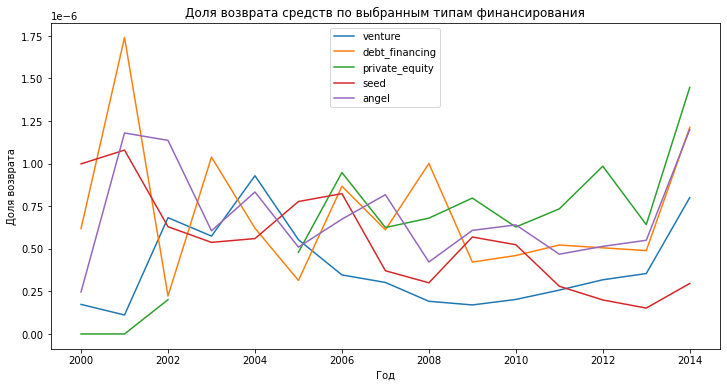

In [85]:
returns_selected.plot(figsize=(12, 6))

plt.title('Доля возврата средств по выбранным типам финансирования')
plt.ylabel('Доля возврата')
plt.xlabel('Год')

plt.show()

Наиболее устойчивый рост доли возврата средств наблюдается у private_equity.

Данный тип финансирования демонстрирует наиболее плавное и последовательное увеличение показателя без резких колебаний.

В меньшей степени устойчивый рост также прослеживается у venture,однако его динамика менее стабильна и сопровождается периодическими снижениями. Остальные типы финансирования (seed, angel, debt_financing) характеризуются высокой волатильностью и не демонстрируют устойчивого роста показателя.


## Шаг 5. Итоговый вывод и рекомендации

Итоговый вывод и рекомендации  

Рекомендации заказчику (на 2015 год)  

**1. В какую отрасль инвестировать**  

Наиболее перспективными для инвестирования являются массовые сегменты, демонстрирующие устойчивый рост финансирования:  

- Technology  
- Internet  
- E-commerce  

Эти сегменты показывают:  
- стабильный рост объёмов инвестиций к 2014 году  
- высокую активность рынка  
- устойчивый интерес со стороны инвесторов  

Особенно выделяется сегмент **Technology**, который демонстрирует наибольшие объёмы финансирования и уверенную динамику роста.  

---

**2. Какой тип финансирования выбрать**  

Наиболее уместным типом финансирования является:  

- **private_equity** (в приоритете)  
- **venture** (как альтернатива)  

**Обоснование:**  

**private_equity:**  
- наиболее устойчивый рост доли возвратов  
- более предсказуемая доходность  
- подходит для зрелых проектов  

**venture:**  
- участие в быстрорастущих компаниях  
- умеренный рост возвратов  
- баланс риска и доходности  

Менее предпочтительные:  
- seed и angel — высокая волатильность  
- debt_financing — нестабильная динамика  

---

Итоги проекта  

**1. Выполненные шаги**  

- проведена очистка данных  
  - удалены аномалии  
  - выполнена фильтрация  

- рассчитаны ключевые метрики  
  - средний размер раунда  
  - количество раундов по годам  
  - объёмы инвестиций по сегментам  
  - доля возвратов  

- построены графики  
  - динамика рынка  
  - распределения  
  - возвраты  

---

**2. Основные выводы**  

- рынок рос до 2013 года, затем в 2014 наблюдается снижение активности  
- средний размер раунда снижается после пика  
- массовые сегменты показывают устойчивый рост  
- возвраты в целом остаются низкими  
- зрелые типы финансирования более стабильны  

---

**3. Согласованность выводов**  

Выводы в целом согласуются:  

- рост сегментов подтверждается динамикой раундов  
- снижение среднего чека отражает изменение структуры рынка  
- низкие возвраты соответствуют долгосрочной природе инвестиций  

**Ограничения:**  

- возможна неполнота данных по возвратам  
- задержки фиксации результатов  
- высокая волатильность отдельных сегментов  